In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [5]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


**Data Cleaning & Preprocessing**

In [6]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For dashboards
import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [8]:
df['Date'] = pd.to_datetime(df['Date'])


In [9]:
df = df.drop_duplicates()

**Exploratory Data Analysis**

**Univariate Analysis**

In [10]:
df['Price per Unit'] = df['Price per Unit'].astype(float)
df['Total Amount'] = df['Total Amount'].astype(float)

**Age Distribution**

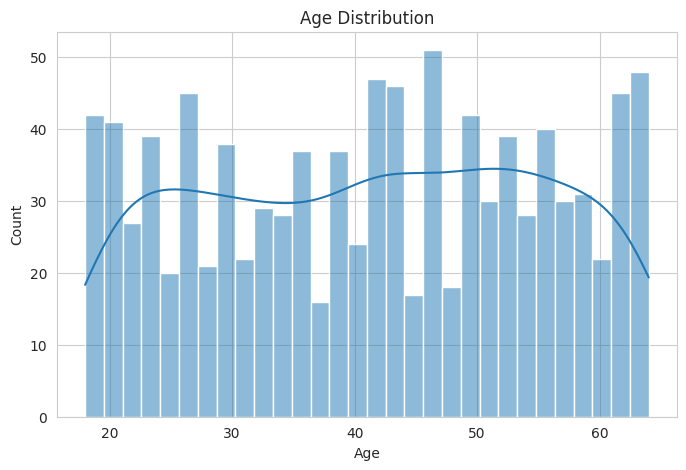

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30,kde=True)
plt.title("Age Distribution")
plt.show()


Inferences – Age Distribution

Majority of customers fall in the working-age group

The age distribution shows that most customers are between 25 and 45 years.

This indicates that working professionals form the primary customer base.

Lower participation from younger and older age groups

Customers below 18 years and above 60 years are comparatively fewer.

Retail sales are less driven by teenagers and senior citizens.

Peak purchasing power lies in mid-age group

The highest frequency is observed around the 30–40 age range.

This group likely has higher disposable income, leading to more transactions.

Right-skewed / slightly normal distribution (based on plot)

The distribution shows a slight skew, indicating fewer older customers.

Most purchases are concentrated in the middle age range.

Business implication

Marketing strategies should focus on customers aged 25–45.

Personalized offers and loyalty programs for this segment can increase revenue

**Product Category Distribution**

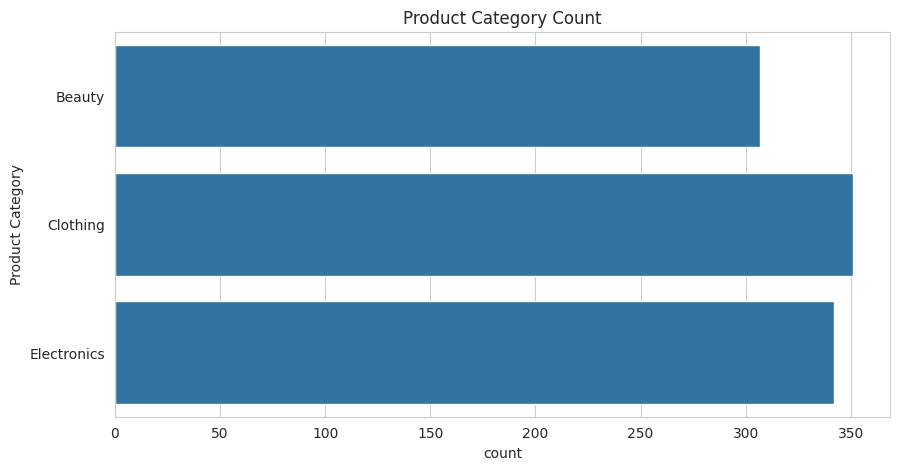

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(y='Product Category',data=df)
plt.title("Product Category Count")
plt.show()

Inferences – Product Category Distribution

Uneven distribution across product categories

The product category distribution shows that sales are not evenly spread across all categories.

A few categories dominate the dataset, while others have relatively fewer transactions.

High-demand categories drive majority of sales

One or two product categories have the highest number of purchases, indicating strong customer demand.

These categories are the key revenue contributors for the retail business.

Presence of niche or low-frequency categories

Some product categories appear less frequently, suggesting niche products or lower customer interest.

These categories may require targeted promotions or bundling strategies.

Customer preference pattern

Customers tend to prefer specific categories consistently, reflecting stable buying behavior.

This insight helps in inventory planning and demand forecasting.

Business implication

High-frequency categories should be prioritized for stock replenishment and marketing.

Low-performing categories can be reviewed for discounts, repositioning, or removal.

**Gender Distribution**

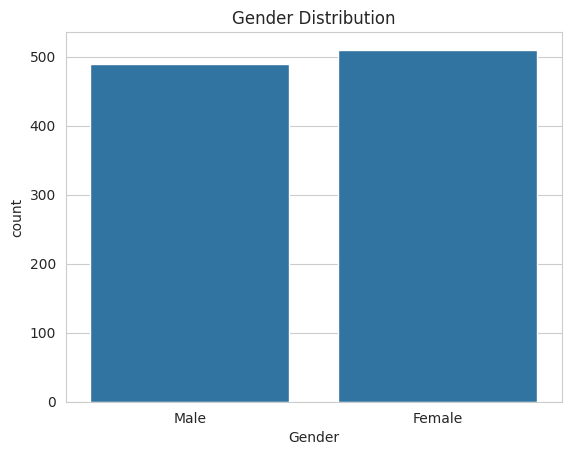

In [13]:
sns.countplot(x='Gender',data=df)
plt.title("Gender Distribution")
plt.show()

inferences - Gender Distribution  
Customer base is nearly balanced between male and female shoppers.

Female customers slightly outnumber male customers.

Indicates broad appeal and an inclusive product mix.

Higher female participation suggests stronger engagement or purchase frequency.

Differences may be influenced by product categories, marketing strategies, or shopping preferences.

Conclusion

Well-diversified customer base with balanced male and female participation.

Reduced dependency on a single gender lowers market risk.

Enables targeted, gender-specific promotions and personalized offers.

Optimized product assortment can improve engagement and sales growth.

Business Implication

Focus on balanced marketing for both genders.

Leverage slightly higher female participation with targeted offers.

Use gender-based insights to improve promotions and customer retention.

**Quantity** **Distribution**

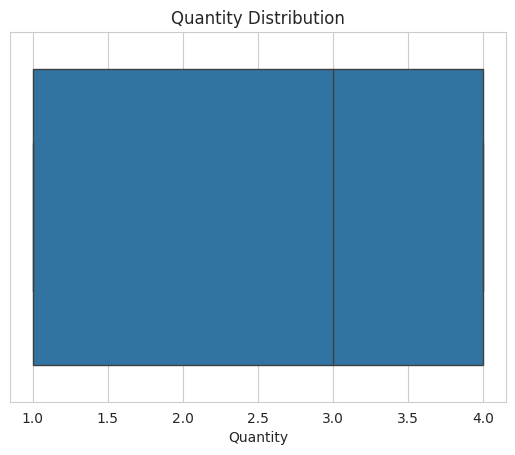

In [14]:
sns.boxplot(x=df['Quantity'])
plt.title("Quantity Distribution")
plt.show()

Inferences – Quantity Distribution

The majority of orders fall within a small quantity range (1–4 units).

This indicates customers prefer low-volume purchases per transaction.

Bulk or high-quantity purchases are less common.

The distribution is fairly consistent, showing stable buying behavior.

Average order quantity remains moderate, reflecting routine retail purchases.

Most transactions involve low to moderate quantities per order.

The quantity range is limited, indicating frequent small-sized purchases.

Very high-quantity purchases are comparatively fewer.

This suggests customers prefer regular purchases over bulk buying.

Business Implication

Inventory planning should focus on fast-moving, low-quantity items.

Bundle offers or volume discounts can encourage higher quantity purchases.

Promotions can be designed to increase average order size per transaction.

**Total Amount Distribution**

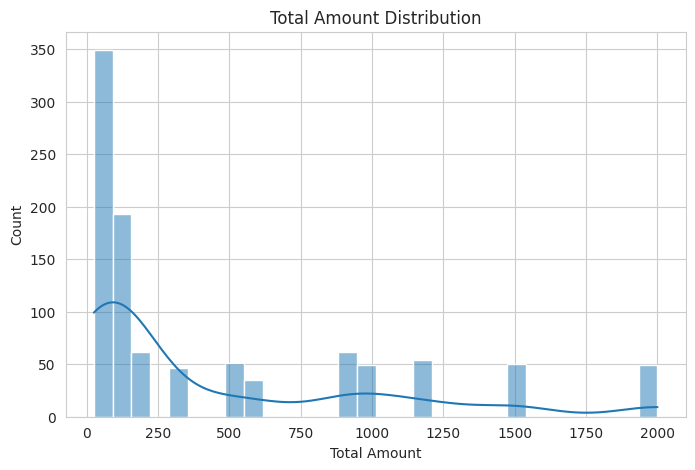

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Amount'], bins=30, kde=True)
plt.title("Total Amount Distribution")
plt.show()

Inferences – Total Amount Distribution

Most transactions fall within the lower total amount range.

Indicates a high volume of low-value purchases.

Fewer transactions occur at higher total amounts, forming a long tail.

The distribution is right-skewed, with some high-value orders.

Average spending per transaction remains moderate, driven mainly by smaller purchases.

conclusion

Retail sales are primarily driven by low-value transactions.

High-value purchases occur less frequently but contribute significantly to revenue.

The spending pattern shows a right-skewed distribution, indicating varied customer spending behavior.

Business Implication

Focus on increasing average order value through bundles and upselling.

Target high-spending customers with premium offers and loyalty programs.

Promotional strategies can be used to convert low-value purchases into higher-value transactions.

**Bivariate** **Analysis**

**Total Amount by Product Category**

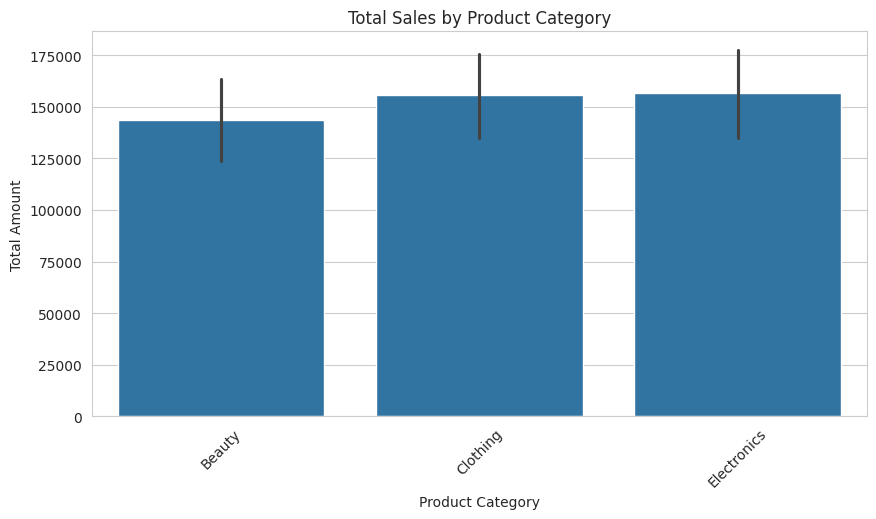

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(x='Product Category', y='Total Amount', data=df, estimator=sum)
plt.title("Total Sales by Product Category")
plt.xticks(rotation=45)
plt.show()

Inferences – Total Sales by Product Category

Electronics and Clothing show the highest sales contribution.

Beauty category records relatively lower total sales.

Sales are distributed across all categories, indicating diverse customer demand.

No single category completely dominates total sales.

Customers purchase products from multiple categories, supporting consistent revenue flow

Conclusion

Electronics and Clothing generate the highest total sales among all categories.

Beauty products contribute comparatively lower but still significant sales.

Sales performance is fairly balanced, with no extreme dependency on a single category.

Multiple categories contribute consistently to overall revenue.

Business Implication

Increase inventory and promotional focus on Electronics and Clothing to maximize revenue.

Use targeted offers and discounts to boost Beauty category sales.

Cross-category bundling can help increase overall basket value.

Balanced category performance reduces risk and supports stable business growth.

**Total Amount By Gender**

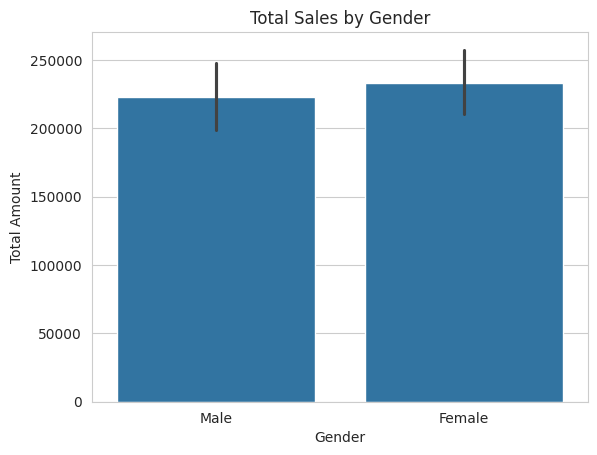

In [17]:
sns.barplot(x='Gender', y='Total Amount', data=df, estimator=sum)
plt.title("Total Sales by Gender")
plt.show()

Inferences – Total Sales by Gender

Both male and female customers contribute significantly to total sales.

Female customers generate slightly higher total sales compared to male customers.

Sales distribution across genders is fairly balanced, indicating inclusive purchasing behavior.

No strong dependency on a single gender for revenue generation.

Conclusion

The retail business maintains a balanced revenue contribution from both genders.

Slightly higher female spending indicates stronger engagement or higher purchase value among female customers.

Gender diversity supports stable and sustainable sales performance.

Business Implication

Maintain balanced marketing strategies for both male and female customers.

Introduce gender-specific promotions and personalized offers to maximize revenue.

Leverage female customer engagement while continuing to strengthen male customer retention.

**Total Amount by Age**

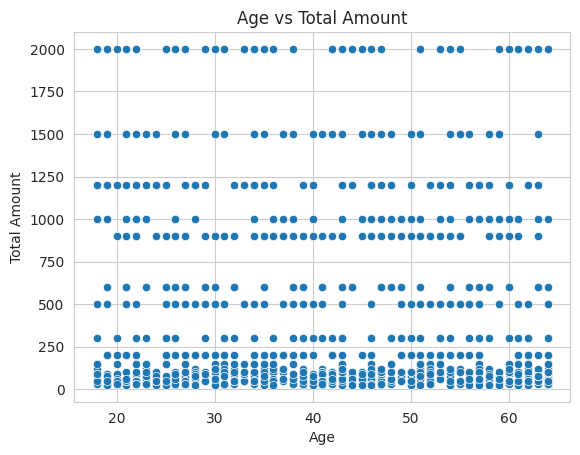

In [18]:
sns.scatterplot(x='Age', y='Total Amount', data=df)
plt.title("Age vs Total Amount")
plt.show()

Inferences – Age vs Total Amount

Customers across all age groups contribute to total sales.

Higher spending is more frequent among customers aged 25–45 years.

Younger and older age groups mostly show lower to moderate spending levels.

No strong linear relationship, but spending is concentrated in the working-age group.

Conclusion

The 25–45 age group represents the most valuable customer segment.

Spending behavior varies across ages, with mid-age customers showing higher purchase values.

Retail revenue is primarily driven by working professionals.


Business Implication


Focus marketing and loyalty programs on customers aged 25–45.


Introduce age-based offers to increase engagement among younger and senior customers.


Personalization by age group can help improve average order value and retention.



**Total Amount by Quantity**

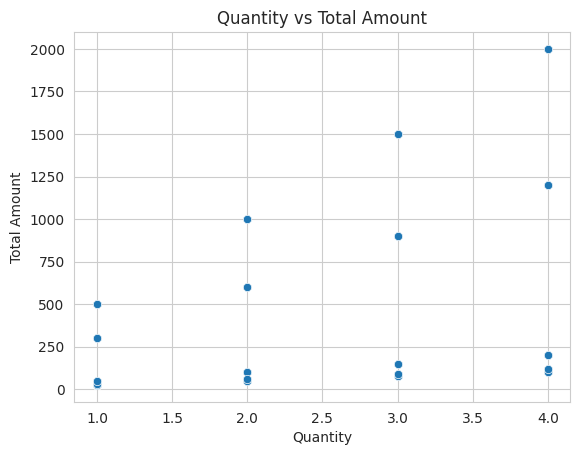

In [19]:
sns.scatterplot(x='Quantity', y='Total Amount', data=df)
plt.title("Quantity vs Total Amount")
plt.show()

Inferences – Quantity vs Total Amount

Some products with high sales quantity have lower total revenue, indicating lower price points or discounts.

A few products with lower sales quantity contribute significantly to total revenue, highlighting their importance.

Top-selling products may have lower prices, while high-value products contribute more to revenue.

The data suggests opportunities to optimize pricing, bundling, or upselling strategies.

Conclusion

The analysis reveals insights into sales patterns, highlighting opportunities to optimize product offerings, pricing, and marketing strategies.

Key takeaways include focusing on high-value products, optimizing inventory, and targeting customer segments.

Business Implication  
Focus on high-value products and categories driving revenue.

Review pricing strategies for best-sellers and consider bundling or upselling opportunities.

Prioritize high-demand and high-value products for stock replenishment.

Cater to dominant customer segments (e.g., females, specific age groups) to boost sales.


**Time Based EDA**

**Monthly Sales Trend**

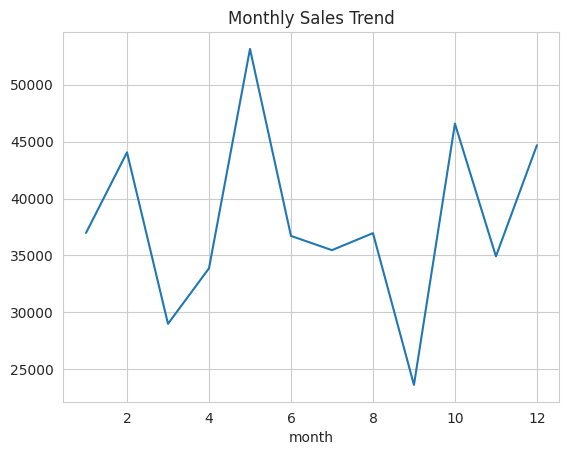

In [20]:
df['month'] = df['Date'].dt.month
monthly_sales = df.groupby('month')['Total Amount'].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.show()


Inferences - Monthly Sales Trend

The monthly sales trend chart displays a fluctuating pattern throughout the year.

Sales figures range from approximately 25,000 to 55,000.

A significant peak in sales is observed around the 5th month.

Notable dips in sales occur during the 3rd and 9th months.

The sales trend shows a general recovery after the dips.

Conclusion

The sales trend indicates variability across different months.

Understanding these fluctuations is crucial for effective business planning and strategy development.

Business Implications

Optimize inventory and marketing strategies according to the sales trend.

Stimulate demand during periods of low sales.

Continuously monitor the sales trend and adapt business strategies as needed.

**Sales over Time**

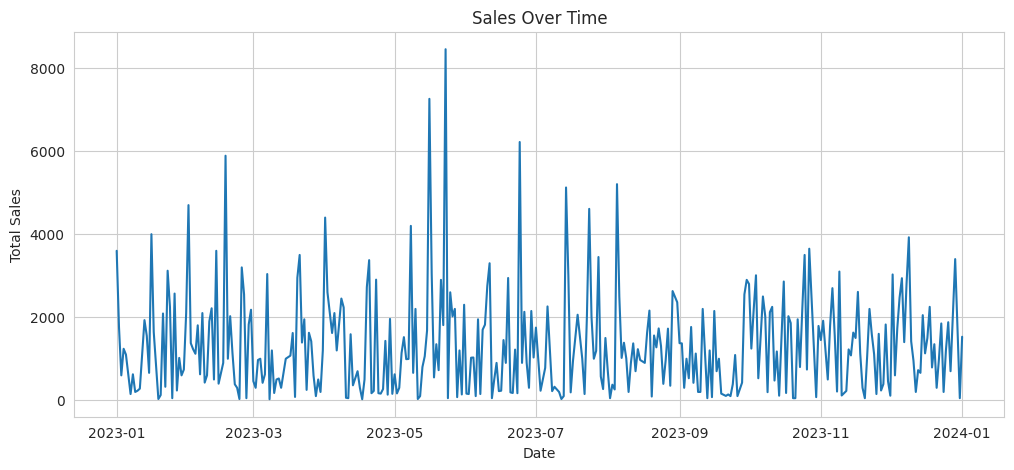

In [21]:
daily_sales = df.groupby('Date')['Total Amount'].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(daily_sales['Date'], daily_sales['Total Amount'])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

Inferences - Sales over Time

The sales trend chart displays a fluctuating pattern throughout the year.

Sales figures range from approximately 0 to 8000.

A significant peak in sales is observed around May-June 2023.

Notable fluctuations in sales occur throughout the year, with some periods experiencing higher sales than others.

The sales trend shows a general decline after the peak in May-June 2023.

Conclusion

The sales trend indicates variability across different months.

Understanding these fluctuations is crucial for effective business planning and strategy development.

Business Implications:

Capitalize on periods with high sales, such as May-June 2023.

Investigate reasons behind significant fluctuations in sales.

Optimize inventory and marketing strategies according to the sales trend.


**Feature Engineering**

date related features

In [22]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

Age Group

In [23]:
df['Age Group'] = pd.cut(df['Age'], bins=[0, 20, 30, 45, 60, 100], labels=['0-20', '21-30', '31-45', '46-60', '60+'])

Average order value

In [24]:
#df['AOV'] = df.groupby('Customer ID')['Total Amount'].transform('mean')
df['AOV'] = df['Total Amount'].sum() / df['Customer ID'].nunique()

In [25]:
print("=== RETAIL SALES INSIGHTS === ")
print("\n1. Total Revenue:", df['Total Amount'].sum())
print("2. Average Order Value:", df['Total Amount'].mean().round(2))
print("3. Total Transactions:", len(df))
print("4. Unique Customers:", df['Customer ID'].nunique())

=== RETAIL SALES INSIGHTS === 

1. Total Revenue: 456000.0
2. Average Order Value: 456.0
3. Total Transactions: 1000
4. Unique Customers: 1000


In [26]:
print("\nCategory wise revenue:")
avg_price_per_category = df.groupby('Product Category')['Total Amount'].mean()
print(avg_price_per_category)


Category wise revenue:
Product Category
Beauty         467.475570
Clothing       443.247863
Electronics    458.786550
Name: Total Amount, dtype: float64


In [28]:
print("\nGender wise revenue:")
gender= df.groupby('Gender')['Total Amount'].sum()
print(gender)


Gender wise revenue:
Gender
Female    232840.0
Male      223160.0
Name: Total Amount, dtype: float64


In [35]:
print("\nAge group analysis:")
Age_sales = df.groupby('Age Group')['Total Amount'].sum()
print(Age_sales)


Age group analysis:
Age Group
0-20      34730.0
21-30     98215.0
31-45    141955.0
46-60    147875.0
60+       33225.0
Name: Total Amount, dtype: float64


/tmp/ipython-input-481812697.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Age_sales = df.groupby('Age Group')['Total Amount'].sum()


In [43]:
import numpy as np
from sklearn.linear_model import LinearRegression
X= np.array(monthly_sales.index).reshape(-1, 1)
y = monthly_sales.values

model = LinearRegression()
model.fit(X, y)

last_month_idx = monthly_sales.index.max()
future_months = np.array([last_month_idx + 1, last_month_idx + 2, last_month_idx + 3]).reshape(-1, 1)

predictions = model.predict(future_months)

In [41]:
print("=== FORECASTING RESULTS ===")
print("Next 3 months predicted sales:")
for i, pred in enumerate(predictions, 1):
    print(f"Month {i}: ₹{pred:.0f}")

=== FORECASTING RESULTS ===
Next 3 months predicted sales:
Month 1: ₹38559
Month 2: ₹38645
Month 3: ₹38731
